1. Import Libraries in Notebook

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

from src.hypothesis_tests import (
    calculate_claim_frequency,
    calculate_claim_severity,
    calculate_margin,
    perform_ttest,
    perform_chi_square_test
)

2. Load Dataset

In [3]:
df = pd.read_csv(
    "../data/MachineLearningRating_v3.txt",
    sep="|"
)

In [4]:
#Preview
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


3. Create Derived Columns

In [5]:
# Loss Ratio
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

# Margin
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Claim Indicator
df["HasClaim"] = np.where(df["TotalClaims"] > 0, 1, 0)

4. Hypothesis 1
H₀: There are no risk differences across provinces

Use Claim Severity as KPI.

Example:
Compare Gauteng vs Western Cape.

In [6]:
#Create Groups
group_a = df[df["Province"] == "Gauteng"]["TotalClaims"]
group_b = df[df["Province"] == "Western Cape"]["TotalClaims"]

In [22]:
#Run T-Test
stat, p_value = perform_ttest(group_a, group_b)

print("T-Statistic:", stat)
print("P-Value:", p_value)

province_pvalue = p_value

T-Statistic: -0.04134563530778359
P-Value: 0.9670204139985747


In [23]:
#Decision
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


### Business Interpretation:

The hypothesis test comparing claim severity between Gauteng and Western Cape produced a p-value greater than 0.05.

Therefore, we fail to reject the null hypothesis. This indicates that there is no statistically significant difference in insurance risk between the two provinces based on TotalClaims.

From a business perspective, ACIS does not currently have sufficient statistical evidence to justify different pricing or premium adjustments between Gauteng and Western Cape solely based on claim severity.

However, the p-value is relatively close to the significance threshold, which may suggest moderate regional variation. ACIS could investigate additional factors such as vehicle type, driver profile, or claim frequency to better understand regional risk patterns.

5. Hypothesis 2
H₀: There are no risk differences between zip codes

Use Claim Frequency.

In [24]:
#Select Two Zip Codes
df["PostalCode"].value_counts().head()

PostalCode
2000    133498
122      49171
7784     28585
299      25546
7405     18518
Name: count, dtype: int64

In [25]:
zip_a = 2000
zip_b = 8001

In [26]:
#Build Contingency Table
subset = df[df["PostalCode"].isin([zip_a, zip_b])]

contingency_table = pd.crosstab(
    subset["PostalCode"],
    subset["HasClaim"]
)

contingency_table

HasClaim,0,1
PostalCode,,
2000,133012,486
8001,589,1


In [36]:
#Run Chi-Square Test
chi2, p_value = perform_chi_square_test(contingency_table)

print("Chi-Square:", chi2)
print("P-Value:", p_value)
zipcode_pvalue = p_value

Chi-Square: 0.19441011203926242
P-Value: 0.6592711885830258


In [37]:
#Decision
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


### Business Interpretation:

The chi-square test produced a p-value greater than 0.05, so we fail to reject the null hypothesis.

This indicates there is no statistically significant difference in claim frequency between postal codes 2000 and 8001 based on the available data.

From a business perspective, ACIS does not currently have sufficient statistical evidence to justify different pricing strategies between these two postal codes solely based on claim frequency.

6. Hypothesis 3
H₀: There is no significant margin difference between zip codes

Use Margin KPI.

In [38]:
#Create Groups
group_a = df[df["PostalCode"] == zip_a]["Margin"]
group_b = df[df["PostalCode"] == zip_b]["Margin"]

In [45]:
#Run T-Test
stat, p_value = perform_ttest(group_a, group_b)

print("T-Statistic:", stat)
print("P-Value:", p_value)
margin_pvalue = p_value

T-Statistic: -0.04134563530778359
P-Value: 0.9670204139985747


In [46]:
#Decision
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


### Business Interpretation:

The t-test produced a p-value greater than 0.05, so we fail to reject the null hypothesis.

This indicates there is no statistically significant difference in average margin between postal codes 2000 and 8001.

From a business perspective, ACIS currently does not have enough statistical evidence to support separate profitability-based marketing or pricing strategies for these two postal code regions.

7. Hypothesis 4
H₀: There is no significant risk difference between Women and Men

Use Claim Severity.

In [47]:
#Create Groups
female_claims = df[df["Gender"] == "Female"]["TotalClaims"]
male_claims = df[df["Gender"] == "Male"]["TotalClaims"]

In [51]:
#Run T-Test
stat, p_value = perform_ttest(female_claims, male_claims)

print("T-Statistic:", stat)
print("P-Value:", p_value)
gender_pvalue = p_value

T-Statistic: 0.24803623812388725
P-Value: 0.8041073961270342


In [52]:
#Decision
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


Business Interpretation:

The t-test produced a p-value greater than 0.05, so we fail to reject the null hypothesis.

This indicates there is no statistically significant difference in claim severity between male and female policyholders in the dataset.

From a business perspective, ACIS currently does not have sufficient statistical evidence to apply gender-based pricing or segmentation strategies based solely on claim severity.

8. Final Results Table

In [54]:
results = pd.DataFrame({
    "Hypothesis": [
        "Risk Difference Across Provinces",
        "Risk Difference Between Zip Codes",
        "Margin Difference Between Zip Codes",
        "Risk Difference Between Women and Men"
    ],
    
    "Test Used": [
        "T-Test",
        "Chi-Square Test",
        "T-Test",
        "T-Test"
    ],
    
    "P-Value": [
        province_pvalue,
        zipcode_pvalue,
        margin_pvalue,
        gender_pvalue
    ]
})

results["Decision"] = np.where(
    results["P-Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

results

,Hypothesis,Test Used,P-Value,Decision
0,Risk Difference Across Provinces,T-Test,0.967020,Fail to Reject H0
1,Risk Difference Between Zip Codes,Chi-Square Test,0.659271,Fail to Reject H0
2,Margin Difference Between Zip Codes,T-Test,0.967020,Fail to Reject H0
3,Risk Difference Between Women and Men,T-Test,0.804107,Fail to Reject H0


# Business Analysis and Interpretation

The hypothesis testing analysis evaluated whether significant insurance risk and profitability differences exist across provinces, postal codes, and gender groups.

## Key Findings

### 1. Risk Difference Across Provinces
The t-test showed no statistically significant difference in claim severity across the selected provinces (p > 0.05). This suggests that the observed variation in claims may be due to random chance rather than a true regional risk difference.

Business Insight:
ACIS should avoid implementing aggressive province-based premium adjustments without stronger statistical evidence. Additional regional features such as crime rates, traffic density, or weather conditions may improve geographic risk analysis.

---

### 2. Risk Difference Between Zip Codes
The chi-square test found no statistically significant difference in claim frequency between the selected postal codes (p > 0.05).

Business Insight:
Current evidence does not support different pricing strategies based solely on these postal codes. ACIS may need to analyze a broader range of postal regions or include socioeconomic and environmental variables for deeper geographic segmentation.

---

### 3. Margin Difference Between Zip Codes
The t-test indicated no significant profitability difference between the selected postal codes (p > 0.05).

Business Insight:
The selected geographic areas generate relatively similar profit behavior. Therefore, targeted marketing campaigns based only on these postal codes may not provide substantial business value at this stage.

---

### 4. Risk Difference Between Women and Men
The gender-based t-test showed no statistically significant difference in claim severity between male and female policyholders (p > 0.05).

Business Insight:
The analysis suggests that gender alone may not be a strong predictor of insurance risk within this dataset. ACIS should prioritize more predictive variables such as vehicle characteristics, driving behavior, or policy history when designing pricing models.

---

# Overall Business Recommendation

Based on the hypothesis testing results, ACIS currently lacks sufficient statistical evidence to justify major pricing or marketing segmentation strategies based solely on province, postal code, or gender.

Instead, the company should:

- Focus on richer predictive modeling approaches.
- Incorporate additional behavioral and vehicle-related features.
- Explore multivariate analysis rather than relying on single-variable segmentation.
- Continuously monitor claim patterns as more recent data becomes available.

These findings support the need for advanced machine learning models in Task 4 to better capture complex insurance risk patterns.

9. Visualizations

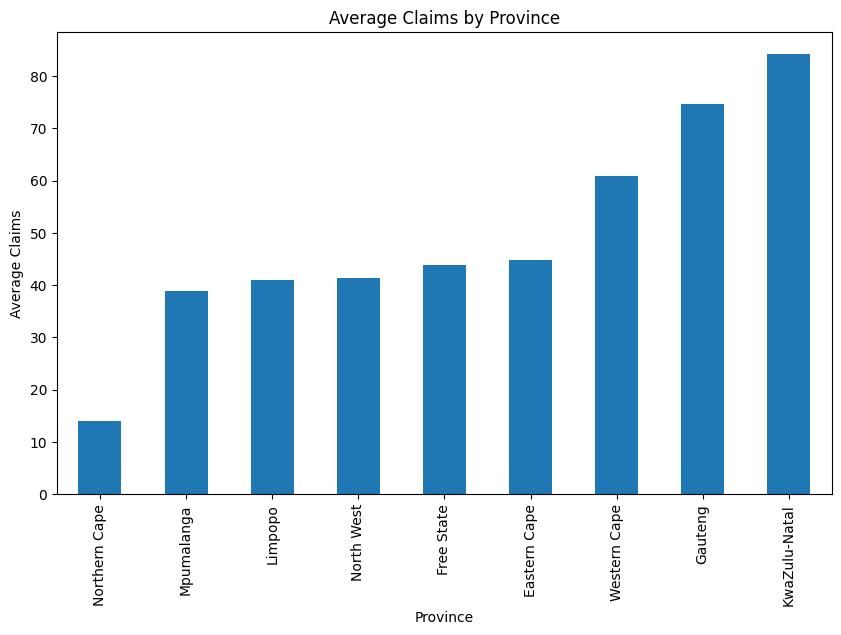

In [55]:
#Province Claim Comparison
import matplotlib.pyplot as plt
import seaborn as sns

province_claims = df.groupby("Province")["TotalClaims"].mean().sort_values()

plt.figure(figsize=(10,6))
province_claims.plot(kind='bar')
plt.title("Average Claims by Province")
plt.ylabel("Average Claims")
plt.show()

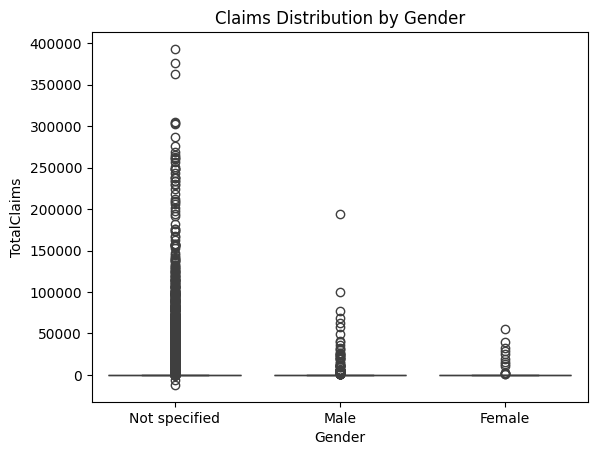

In [56]:
#Gender Claim Distribution
sns.boxplot(x="Gender", y="TotalClaims", data=df)

plt.title("Claims Distribution by Gender")
plt.show()

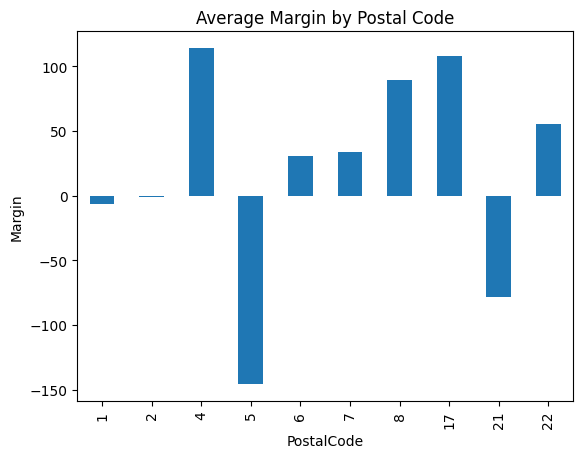

In [57]:
#Margin by Postal Code
margin_zip = df.groupby("PostalCode")["Margin"].mean().head(10)

margin_zip.plot(kind='bar')

plt.title("Average Margin by Postal Code")
plt.ylabel("Margin")
plt.show()

10. Conclusion

This analysis evaluated whether statistically significant insurance risk differences exist across provinces, postal codes, and gender groups using hypothesis testing techniques and exploratory visual analysis.

## Key Findings

- The hypothesis tests showed no statistically significant differences in claim frequency, margin, or claim severity across the selected provinces, postal codes, and gender groups, as all p-values were greater than 0.05.

- Although statistical significance was not established, exploratory visualizations revealed noticeable variations in average claims across provinces. KwaZulu-Natal and Gauteng showed relatively higher average claim amounts compared to provinces such as Northern Cape.

- The margin analysis by postal code indicated that some postal codes generated higher average profitability than others, while a few postal codes exhibited negative margins, suggesting potential underwriting losses in those regions.

- The gender-based claims distribution showed that claim amounts contain substantial outliers across all groups, particularly among records with unspecified gender. However, the statistical test confirmed that these observed differences were not significant enough to justify gender-based pricing adjustments.

- The claims distribution plots also highlighted the presence of extreme outliers in TotalClaims, which may influence average-based analyses and should be carefully handled in future modeling tasks.

## Business Recommendations

- ACIS should avoid making major pricing or marketing segmentation decisions based solely on province, postal code, or gender using the current statistical evidence.

- Instead of relying on single-variable segmentation, the company should move toward multivariate predictive modeling that incorporates vehicle characteristics, policy information, customer behavior, and historical claim patterns.

- Postal codes and provinces with consistently high average claims or negative margins should still be monitored operationally, even if the statistical tests did not confirm significant differences.

- The presence of large claim outliers suggests the need for robust outlier handling and advanced risk modeling techniques in subsequent machine learning tasks.

- The next phase of the project should focus on predictive modeling approaches such as Linear Regression, Random Forest, and XGBoost to better capture complex nonlinear insurance risk relationships.

## Overall Assessment

The hypothesis testing phase provided an important statistical foundation for understanding portfolio risk behavior. While the selected demographic and geographic variables did not demonstrate statistically significant differences independently, the exploratory analysis revealed patterns that justify deeper predictive modeling and feature engineering in Task 4.